In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from numba import njit

# =========================================================
# 1. БЫСТРОЕ ЯДРО (Оси: u1 и alpha_tilde)
# =========================================================
@njit
def detect_period_fast(arr, max_period=20, tol=1e-6):
    n = len(arr)
    for p in range(1, min(max_period, n // 2) + 1):
        is_periodic = True
        for i in range(n - p):
            if abs(arr[i] - arr[i + p]) > tol:
                is_periodic = False
                break
        if is_periodic:
            return p
    return 0

@njit
def compute_map_u1_alpha(u1_vals, alpha_vals, v, u2, N_trans, N_iter, x0, y0):
    rows = len(alpha_vals)
    cols = len(u1_vals)
    regime_map = np.full((rows, cols), -1, dtype=np.int32)
    y_vals = np.empty(N_iter, dtype=np.float64)

    for i in range(rows):
        alpha = alpha_vals[i]

        for j in range(cols):
            u1 = u1_vals[j]

            x, y = x0, y0
            is_overflow = False

            # Прогрев
            for _ in range(N_trans):
                x_new = alpha * y * (1 - y) * (1 - u1)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new

                if abs(x) > 1e10 or abs(y) > 1e10:
                    is_overflow = True
                    break

            if is_overflow:
                regime_map[i, j] = -1
                continue

            # Сбор данных
            for k in range(N_iter):
                x_new = alpha * y * (1 - y) * (1 - u1)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new

                if abs(x) > 1e10 or abs(y) > 1e10:
                    is_overflow = True
                    break
                y_vals[k] = y

            if is_overflow:
                regime_map[i, j] = -1
            else:
                p = detect_period_fast(y_vals, max_period=20, tol=1e-6)
                if p == 0: regime_map[i, j] = 0
                elif p <= 5: regime_map[i, j] = p
                else: regime_map[i, j] = 6

    return regime_map

# =========================================================
# 2. ФУНКЦИЯ ОТРИСОВКИ
# =========================================================
def plot_bifurcation_plane(
    v, u2,
    u1_range=(0.01, 0.99),
    alpha_range=(0, 700),
    resolution=400,
    x0=0.1, y0=0.1
):
    # 1. Сетки
    u1_vals = np.linspace(u1_range[0], u1_range[1], resolution)
    alpha_vals = np.linspace(alpha_range[0], alpha_range[1], resolution)

    print(f"Расчет карты в плоскости (u1, ~alpha)...")

    # 2. Расчет
    map_data = compute_map_u1_alpha(u1_vals, alpha_vals, v, u2, 1000, 100, x0, y0)

    # 3. Визуализация
    color_map = {
        -1: '#E0E0E0', 0: '#000000', 1: '#0000A8', 2: '#00A800',
        3: '#00A8A8', 4: '#A80000', 5: '#A800A8', 6: '#FFA500'
    }
    keys = sorted(color_map.keys())
    cmap = ListedColormap([color_map[k] for k in keys])

    plt.figure(figsize=(10, 8))

    # Рисуем карту
    plt.imshow(
        map_data,
        extent=[u1_range[0], u1_range[1], alpha_range[0], alpha_range[1]],
        origin='lower', aspect='auto', cmap=cmap,
        vmin=keys[0] - 0.5, vmax=keys[-1] + 0.5
    )


    # Оформление
    cbar = plt.colorbar(ticks=keys)
    label_map = {-1: 'Убегает на беск.', 0: 'Хаос', 1: 'период-1', 2: 'период-2', 3: 'период-3', 4: 'период-4', 5: 'период-5', 6: 'период > 5'}
    cbar.ax.set_yticklabels([label_map[k] for k in keys])

    plt.xlabel('u1')
    plt.ylabel('~alpha (tilda)')
    plt.title(f'Карта режимов (Без линий)\n(v={v}, u2={u2})')
    plt.show()

# =========================================================
# ЗАПУСК
# =========================================================

Расчет карты в плоскости (u1, ~alpha)...


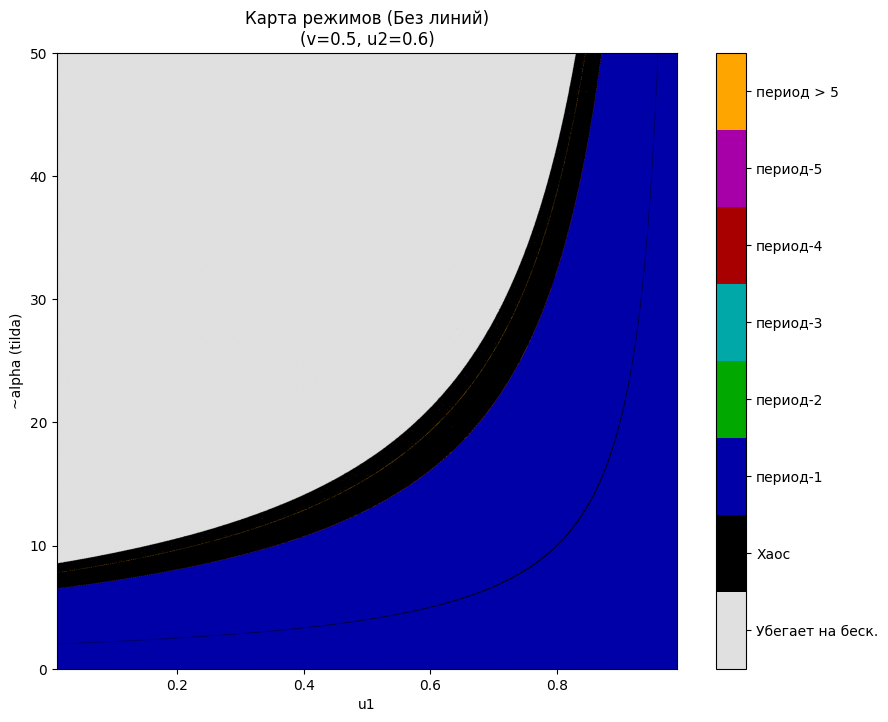

In [30]:
plot_bifurcation_plane(v=0.5, u2=0.6, u1_range=(0.01, 0.99), alpha_range=(0, 50), resolution=1800)

Расчет карты в плоскости (u1, ~alpha)...


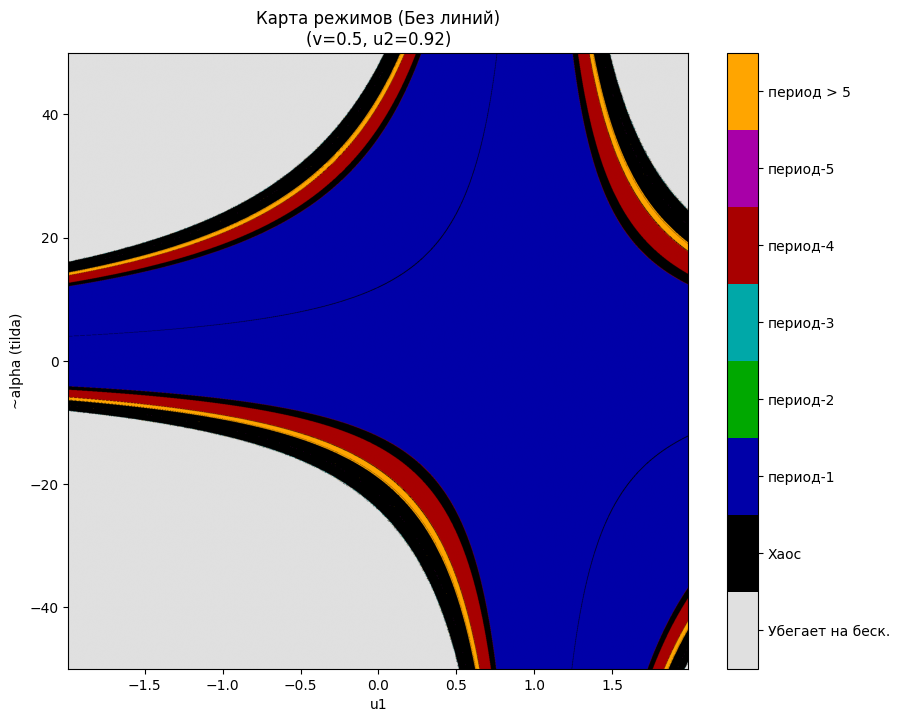

In [37]:
plot_bifurcation_plane(v=0.5, u2=0.92, u1_range=(-1.99, 1.99), alpha_range=(-50, 50), resolution=1800)

Расчет карты в плоскости (u1, ~alpha)...


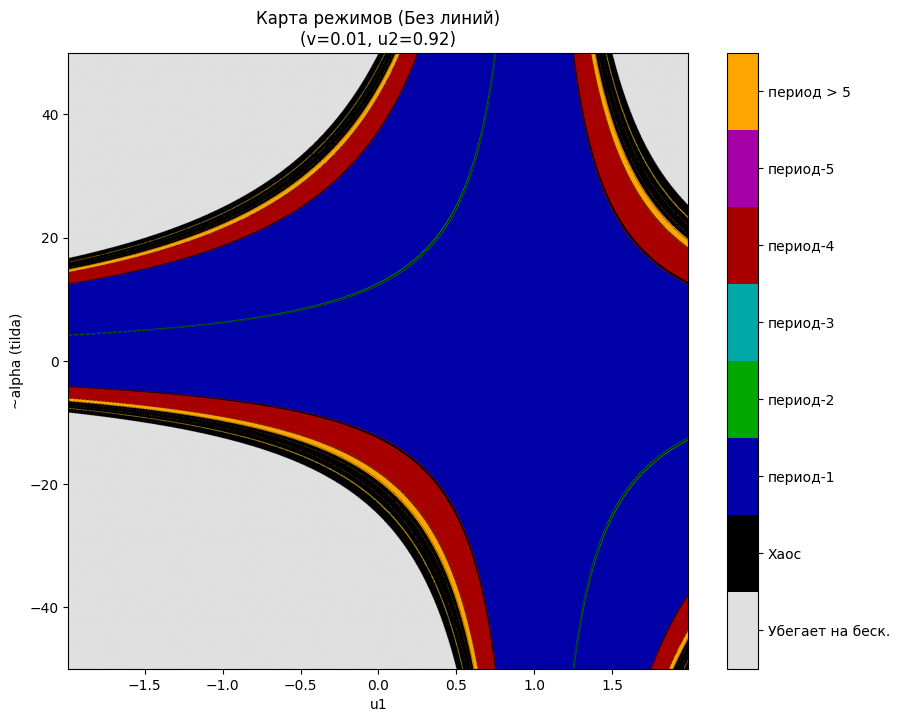

In [40]:
plot_bifurcation_plane(v=0.01, u2=0.92, u1_range=(-1.99, 1.99), alpha_range=(-50, 50), resolution=1800)